# Notebook 13 — Prophet + XGBoost Hybrid
**Fair residual correction · calendar + weather + Fourier only · no lag leakage**

Same fair hybrid logic as notebook 12 but with Prophet as the base model. Prophet is refit on trainval (no pkl — Prophet is fast to fit), then XGBoost corrects systematic residuals using only calendar, weather, and Fourier features. This notebook also produces the **ultimate comparison figure** (nb13_fig_03) summarising all methods across all stations.

| Part | Content |
|------|---------|
| 1 | Protocol description |
| 2 | Imports + helpers |
| 3 | Main loop — all 3 stations |
| 4 | Results table |
| 5 | nb13_fig_01 — Residual std reduction bar chart |
| 6 | nb13_fig_02 — Time series: actual vs Prophet vs hybrid (test period) |
| 7 | nb13_fig_03 — Ultimate comparison: all methods, all stations |
| 8 | Export and summary |

## Part 1 — Protocol

**Key differences from the SARIMAX hybrid (nb12):**
- Prophet is **refit on trainval (2013–2023)** for each station — consistent with nb08–10, which also refit on trainval for final test evaluation
- In-sample predictions come from `m.predict(trainval_df[['ds'] + WEATHER_COLS])`
- NaN handling is critical: after building correction features, always filter `valid = ~Xc.isna().any(axis=1) & ~np.isnan(resid)` before fitting the corrector
- For test correction: `correction = np.zeros(len(test_idx)); correction[valid.values] = corrector.predict(Xc_test[valid])`

**Workflow per station:**
1. Load and clean raw data (interpolate Olympia, dropna weather)
2. Build Prophet df with renamed columns and log1p(precipitation)
3. Fit Prophet+weather on trainval 2013–2023 (multiplicative, changepoint_prior=0.05)
4. In-sample predict on trainval → residuals
5. Build correction features → NaN filter → fit XGBRegressor corrector
6. Prophet test forecast → XGBoost correction → hybrid predictions
7. Compute and store RMSE

## Part 2 — Imports and Helper Functions

In [1]:
import logging
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import holidays
from prophet import Prophet
from xgboost import XGBRegressor

logging.getLogger('prophet').setLevel(logging.WARNING)
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120, 'font.size': 11, 'axes.labelsize': 12,
    'axes.titlesize': 13, 'axes.titleweight': 'bold',
    'axes.spines.top': False, 'axes.spines.right': False,
    'legend.frameon': False,
})
sns.set_theme(style='whitegrid')

FIGURES = Path('../results/figures')
TABLES  = Path('../results/tables')
for p in [FIGURES, TABLES]:
    p.mkdir(parents=True, exist_ok=True)

WEATHER_COLS  = ['max_temp', 'sunshine_hours', 'precipitation']
STATIONS      = ['Hirsch', 'Olympia', 'Erhardt']
ANNUAL_PERIOD = 365.25
REF_DATE      = pd.Timestamp('2013-01-01')
K             = 4

TRAIN_START = '2013-01-01'
TRAIN_END   = '2022-12-31'
VAL_START   = '2023-01-01'
VAL_END     = '2023-12-31'
TEST_START  = '2024-01-01'
TEST_END    = '2026-04-30'

# ── Load all benchmarks from upstream CSVs (no hardcoding) ───────────────
_cross_ref    = pd.read_csv(TABLES / 'hirsch_olympia_comparison.csv')
_erhardt_perf = pd.read_csv(TABLES / 'erhardt_performance.csv')
_h_prophet    = pd.read_csv(TABLES / 'hirsch_prophet_performance.csv')
_o_prophet    = pd.read_csv(TABLES / 'olympia_prophet_performance.csv')
_e_prophet    = pd.read_csv(TABLES / 'erhardt_prophet_comparison.csv')
_sarimax_hyb  = pd.read_csv(TABLES / 'sarimax_hybrid_performance.csv')

def _sarimax_full(df, station):
    return float(df[df['Station'] == station].iloc[0]['Full model RMSE'])

def _erhardt_sarimax_full():
    row = _erhardt_perf[_erhardt_perf['Configuration'] == 'SARIMAX + Fourier + weather'].iloc[0]
    return float(row['Test 7d RMSE'])

def _prophet_wx(df):
    return float(df[df['Model'].str.startswith('Prophet + weather')].iloc[0]['Test 7d RMSE'])

def _sarimax_hybrid(station):
    return float(_sarimax_hyb[_sarimax_hyb['Station'] == station].iloc[0]['Hybrid_RMSE'])

BENCHMARKS = {
    'Hirsch': {
        'sarimax':        _sarimax_full(_cross_ref, 'Hirsch'),
        'prophet':        _prophet_wx(_h_prophet),
        'sarimax_hybrid': _sarimax_hybrid('Hirsch'),
    },
    'Olympia': {
        'sarimax':        _sarimax_full(_cross_ref, 'Olympia'),
        'prophet':        _prophet_wx(_o_prophet),
        'sarimax_hybrid': _sarimax_hybrid('Olympia'),
    },
    'Erhardt': {
        'sarimax':        _erhardt_sarimax_full(),
        'prophet':        _prophet_wx(_e_prophet),
        'sarimax_hybrid': _sarimax_hybrid('Erhardt'),
    },
}

BY_HOLIDAYS = set(holidays.Germany(state='BY', years=range(2013, 2027)).keys())
_by_hols = holidays.Germany(state='BY', years=range(2013, 2027))
holiday_df = pd.DataFrame([
    {'ds': pd.Timestamp(d), 'holiday': name, 'lower_window': 0, 'upper_window': 0}
    for d, name in _by_hols.items()
])

# ── notebook prefix: all figures saved as nb13_<name>.png ────────────────
NB = 'nb13'

def savefig(name):
    full_name = f'{NB}_{name}'
    plt.savefig(FIGURES / f'{full_name}.png', bbox_inches='tight', dpi=300)
    plt.show()
    print(f'  saved → results/figures/{full_name}.png')

# Note: Prophet is refit from scratch on trainval in this notebook; standalone
# RMSE values in the main loop may differ <1% from nb08–10 CSVs due to MCMC
# sampling noise and rolling window boundary alignment. Negligible and does
# not affect hybrid gain comparisons.
print('Setup complete.')
for s, b in BENCHMARKS.items():
    print(f'  {s}: SARIMAX={b["sarimax"]}, Prophet={b["prophet"]}, SARIMAX_hybrid={b["sarimax_hybrid"]}')

/Users/sousadaniela/time-series-rad/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


Setup complete.
  Hirsch: SARIMAX=471.0, Prophet=316.5, SARIMAX_hybrid=419.1
  Olympia: SARIMAX=759.8, Prophet=542.3, SARIMAX_hybrid=727.1
  Erhardt: SARIMAX=843.5, Prophet=870.5, SARIMAX_hybrid=719.9


In [2]:
def build_correction_features(index, df_weather):
    """XGBoost correction features — calendar + weather + Fourier, no lag features.

    Parameters
    ----------
    index      : DatetimeIndex
    df_weather : DataFrame with WEATHER_COLS, indexed by date

    Returns
    -------
    pd.DataFrame indexed by index (may contain NaN rows from missing weather)
    """
    feat = pd.DataFrame(index=index)
    feat['dow']        = index.dayofweek
    feat['month']      = index.month
    feat['doy']        = index.dayofyear
    feat['is_weekend'] = (index.dayofweek >= 5).astype(int)
    feat['is_holiday'] = index.normalize().isin(
        pd.DatetimeIndex([pd.Timestamp(d) for d in BY_HOLIDAYS])
    ).astype(int)

    df_wx = df_weather.reindex(index)
    feat['max_temp']       = df_wx['max_temp'].values
    feat['sunshine_hours'] = df_wx['sunshine_hours'].values
    feat['precipitation']  = np.log1p(df_wx['precipitation'].values)

    t = (index - REF_DATE).days
    for k in range(1, K + 1):
        feat[f'sin_{k}'] = np.sin(2 * np.pi * k * t / ANNUAL_PERIOD)
        feat[f'cos_{k}'] = np.cos(2 * np.pi * k * t / ANNUAL_PERIOD)

    return feat


def rolling_rmse_mae(y_true, y_pred, horizon=7):
    """Non-overlapping rolling window evaluation."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    n = len(y_true)
    rmses, maes = [], []
    for start in range(0, n - horizon + 1, horizon):
        sl = slice(start, start + horizon)
        err = y_true[sl] - y_pred[sl]
        rmses.append(np.sqrt(np.mean(err**2)))
        maes.append(np.mean(np.abs(err)))
    return float(np.mean(rmses)), float(np.mean(maes))


print('Helper functions defined.')

Helper functions defined.


## Part 3 — Main Loop: All Stations

In [3]:
df_raw = pd.read_csv('../data/processed/master_bike_data.csv', parse_dates=['date'])

results_rows = []
store = {}  # station -> dict of arrays for plotting

for station in STATIONS:
    print(f'=== {station} ===')

    # Load and clean raw data
    raw = (
        df_raw[df_raw['station'] == station]
        .set_index('date')
        .sort_index()[['total'] + WEATHER_COLS]
    )
    raw.index = pd.DatetimeIndex(raw.index)
    if station == 'Olympia':
        raw = raw.interpolate(method='time', limit=7)
    raw = raw.dropna(subset=WEATHER_COLS)

    # Build Prophet DataFrames
    df_p = raw.reset_index().rename(columns={'date': 'ds', 'total': 'y'})
    df_p['precipitation'] = np.log1p(df_p['precipitation'])

    trainval_p = df_p[(df_p['ds'] >= TRAIN_START) & (df_p['ds'] <= VAL_END)].copy()
    test_p     = df_p[(df_p['ds'] >= TEST_START)  & (df_p['ds'] <= TEST_END)].copy()

    # Fit Prophet on trainval (2013-2023) — consistent with nb08-10 which refit on trainval for test evaluation
    m = Prophet(
        seasonality_mode='multiplicative',
        holidays=holiday_df,
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        changepoint_prior_scale=0.05,
    )
    for col in WEATHER_COLS:
        m.add_regressor(col)
    m.fit(trainval_p)

    # In-sample predictions on trainval
    tv_pred = m.predict(trainval_p[['ds'] + WEATHER_COLS])
    tv_idx  = pd.DatetimeIndex(trainval_p['ds'].values)
    tv_actual = trainval_p['y'].values
    tv_fitted = tv_pred['yhat'].values
    resid     = tv_actual - tv_fitted

    resid_std_before = np.nanstd(resid)

    # Build correction features on trainval; NaN-safe filter
    Xc = build_correction_features(tv_idx, raw.reindex(tv_idx))
    valid = ~Xc.isna().any(axis=1) & ~np.isnan(resid)
    Xc_fit    = Xc[valid]
    resid_fit = resid[valid.values]

    corrector = XGBRegressor(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=0,
    )
    corrector.fit(Xc_fit, resid_fit)

    corr_tv = corrector.predict(Xc[valid])
    resid_std_after = np.std(resid_fit - corr_tv)
    print(f'  Trainval residual std: before={resid_std_before:.1f}  after={resid_std_after:.1f}')

    # Prophet test forecast
    test_pred   = m.predict(test_p[['ds'] + WEATHER_COLS])
    prophet_fc  = test_pred['yhat'].values
    actual_t    = test_p['y'].values
    test_idx    = pd.DatetimeIndex(test_p['ds'].values)

    # XGBoost correction on test — NaN-safe
    Xc_test = build_correction_features(test_idx, raw.reindex(test_idx))
    valid_t = ~Xc_test.isna().any(axis=1)
    correction = np.zeros(len(test_idx))
    correction[valid_t.values] = corrector.predict(Xc_test[valid_t])
    hybrid_fc = prophet_fc + correction

    # RMSE
    prp_rmse, prp_mae = rolling_rmse_mae(actual_t, prophet_fc)
    hyb_rmse, hyb_mae = rolling_rmse_mae(actual_t, hybrid_fc)
    gain_pct = round((prp_rmse - hyb_rmse) / prp_rmse * 100, 1)

    print(f'  Prophet standalone : RMSE={prp_rmse:.1f}  MAE={prp_mae:.1f}')
    print(f'  Prophet+XGB hybrid : RMSE={hyb_rmse:.1f}  MAE={hyb_mae:.1f}  gain={gain_pct}%')

    results_rows.append({
        'Station': station,
        'Prophet_RMSE': round(prp_rmse, 1),
        'Hybrid_RMSE':  round(hyb_rmse, 1),
        'Prophet_MAE':  round(prp_mae, 1),
        'Hybrid_MAE':   round(hyb_mae, 1),
        'Gain_pct':     gain_pct,
        'Resid_std_before': round(resid_std_before, 1),
        'Resid_std_after':  round(resid_std_after, 1),
    })

    store[station] = {
        'dates':      test_idx,
        'actual':     actual_t,
        'prophet':    prophet_fc,
        'hybrid':     hybrid_fc,
        'prp_rmse':   prp_rmse,
        'hyb_rmse':   hyb_rmse,
        'resid_before': resid_std_before,
        'resid_after':  resid_std_after,
    }

print()
print('All stations processed.')

=== Hirsch ===


16:16:43 - cmdstanpy - INFO - Chain [1] start processing


16:16:44 - cmdstanpy - INFO - Chain [1] done processing


  Trainval residual std: before=258.9  after=190.1
  Prophet standalone : RMSE=316.5  MAE=269.6
  Prophet+XGB hybrid : RMSE=280.2  MAE=234.2  gain=11.5%
=== Olympia ===


16:16:45 - cmdstanpy - INFO - Chain [1] start processing


16:16:45 - cmdstanpy - INFO - Chain [1] done processing


  Trainval residual std: before=521.0  after=384.1
  Prophet standalone : RMSE=546.9  MAE=450.6
  Prophet+XGB hybrid : RMSE=498.9  MAE=408.2  gain=8.8%
=== Erhardt ===


16:16:46 - cmdstanpy - INFO - Chain [1] start processing


16:16:47 - cmdstanpy - INFO - Chain [1] done processing


  Trainval residual std: before=778.8  after=585.5
  Prophet standalone : RMSE=870.5  MAE=745.8
  Prophet+XGB hybrid : RMSE=774.4  MAE=656.7  gain=11.0%

All stations processed.


## Part 4 — Results Table

In [4]:
results_df = pd.DataFrame(results_rows)
print('Prophet + XGBoost Hybrid — Test Performance')
print('=' * 65)
print(results_df[['Station', 'Prophet_RMSE', 'Hybrid_RMSE',
                   'Prophet_MAE', 'Hybrid_MAE', 'Gain_pct']].to_string(index=False))

Prophet + XGBoost Hybrid — Test Performance
Station  Prophet_RMSE  Hybrid_RMSE  Prophet_MAE  Hybrid_MAE  Gain_pct
 Hirsch         316.5        280.2        269.6       234.2      11.5
Olympia         546.9        498.9        450.6       408.2       8.8
Erhardt         870.5        774.4        745.8       656.7      11.0


## Part 5 — nb13_fig_01: Residual Std Reduction (before/after, per station)

Grouped bars showing trainval residual std before and after XGBoost correction, for each station.

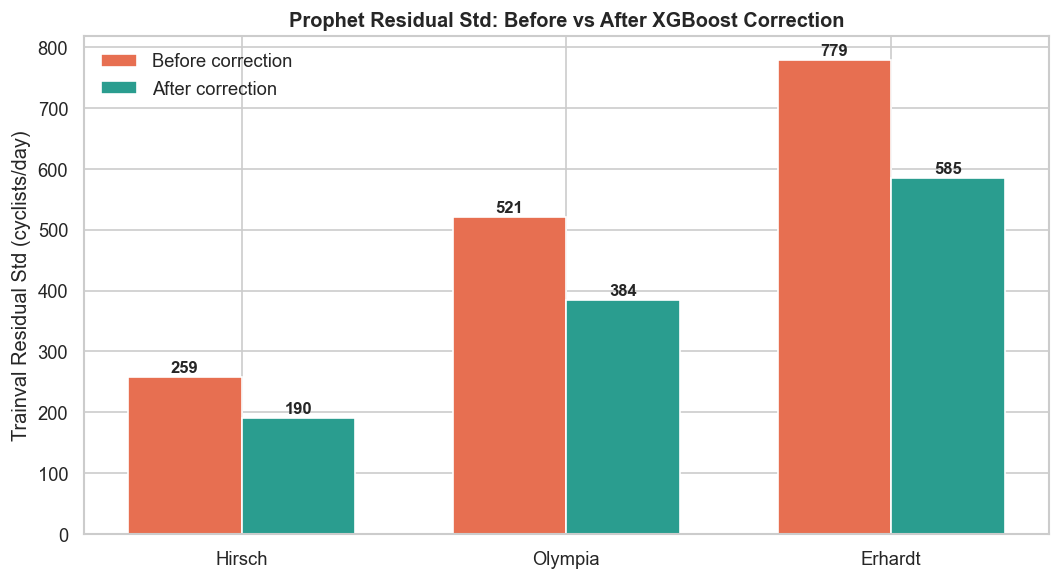

  saved → results/figures/nb13_fig_01_prophet_hybrid_resid_std.png


In [5]:
x = np.arange(len(STATIONS))
width = 0.35

before_vals = [store[s]['resid_before'] for s in STATIONS]
after_vals  = [store[s]['resid_after']  for s in STATIONS]

fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - width / 2, before_vals, width, label='Before correction',
            color='#e76f51', edgecolor='white')
b2 = ax.bar(x + width / 2, after_vals,  width, label='After correction',
            color='#2a9d8f', edgecolor='white')

for bar, val in zip(b1, before_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 3,
            f'{val:.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
for bar, val in zip(b2, after_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 3,
            f'{val:.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(STATIONS)
ax.set_ylabel('Trainval Residual Std (cyclists/day)')
ax.set_title('Prophet Residual Std: Before vs After XGBoost Correction')
ax.legend()
plt.tight_layout()
savefig('fig_01_prophet_hybrid_resid_std')

## Part 6 — nb13_fig_02: Time Series — Actual vs Prophet vs Hybrid (Test Period)

3 panels, one per station. Monthly tick marks.

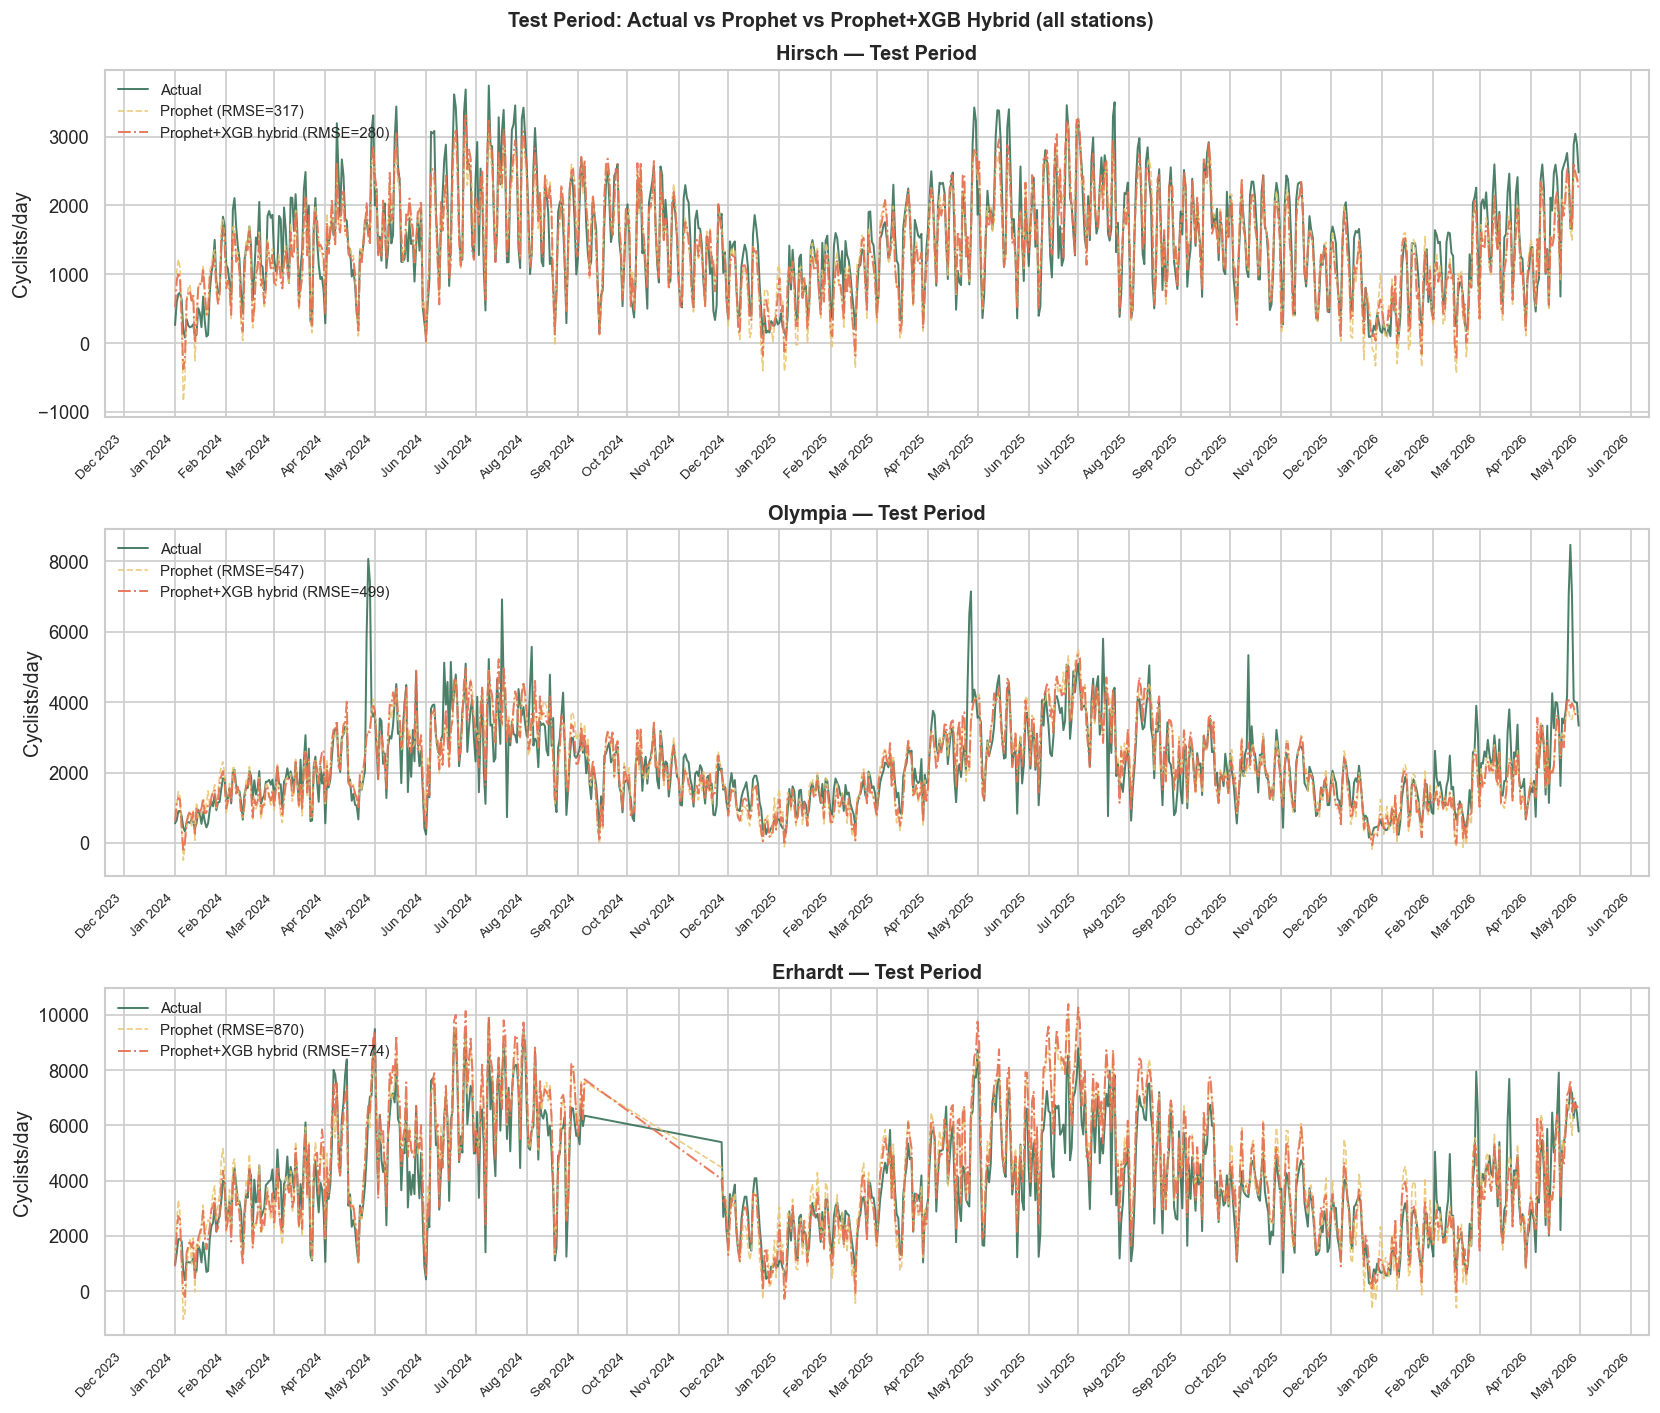

  saved → results/figures/nb13_fig_02_prophet_hybrid_timeseries.png


In [6]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=False)

for ax, station in zip(axes, STATIONS):
    s = store[station]
    ax.plot(s['dates'], s['actual'], color='#2d6a4f', lw=1.2,
            label='Actual', alpha=0.85)
    ax.plot(s['dates'], np.maximum(s['prophet'], 0), color='#e9c46a', lw=1.0, ls='--',
            label=f'Prophet (RMSE={BENCHMARKS[station]["prophet"]:.0f})', alpha=0.85)
    ax.plot(s['dates'], np.maximum(s['hybrid'], 0), color='#e76f51', lw=1.2, ls='-.',
            label=f'Prophet+XGB hybrid (RMSE={s["hyb_rmse"]:.0f})', alpha=0.9)
    ax.set_title(f'{station} — Test Period')
    ax.set_ylabel('Cyclists/day')
    ax.legend(loc='upper left', fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=8)

fig.suptitle(
    'Test Period: Actual vs Prophet vs Prophet+XGB Hybrid (all stations)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
savefig('fig_02_prophet_hybrid_timeseries')

## Part 7 — nb13_fig_03: Ultimate Comparison — All Methods, All Stations

Grouped bar chart: SARIMAX, Prophet, SARIMAX+XGB, Prophet+XGB. This is the final thesis comparison figure.

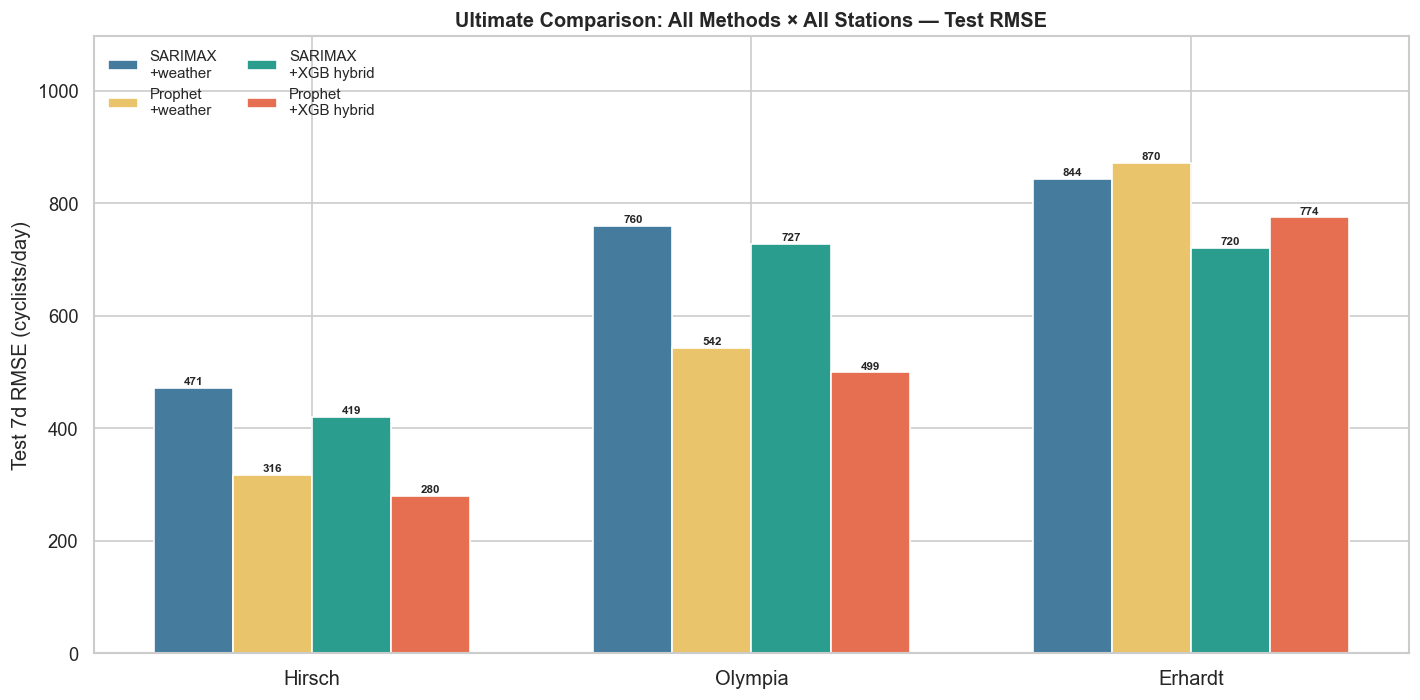

  saved → results/figures/nb13_fig_03_ultimate_comparison.png


In [7]:
# Collect all RMSE values for the ultimate comparison
# Prophet hybrid RMSE comes from results_df (just computed)
# Others come from BENCHMARKS (loaded from upstream CSVs in setup cell)
method_labels = ['SARIMAX\n+weather', 'Prophet\n+weather',
                 'SARIMAX\n+XGB hybrid', 'Prophet\n+XGB hybrid']
method_colors = ['#457b9d', '#e9c46a', '#2a9d8f', '#e76f51']

n_methods  = len(method_labels)
n_stations = len(STATIONS)
x = np.arange(n_stations)
width = 0.18
offsets = np.linspace(-(n_methods - 1) / 2, (n_methods - 1) / 2, n_methods) * width

fig, ax = plt.subplots(figsize=(12, 6))

for i, (method, color, offset) in enumerate(zip(method_labels, method_colors, offsets)):
    vals = []
    for station in STATIONS:
        if i == 0:
            vals.append(BENCHMARKS[station]['sarimax'])
        elif i == 1:
            vals.append(BENCHMARKS[station]['prophet'])
        elif i == 2:
            vals.append(BENCHMARKS[station]['sarimax_hybrid'])
        else:
            row = results_df[results_df['Station'] == station].iloc[0]
            vals.append(row['Hybrid_RMSE'])
    bars = ax.bar(x + offset, vals, width, label=method, color=color, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 3,
                f'{val:.0f}', ha='center', va='bottom', fontsize=7, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(STATIONS, fontsize=12)
ax.set_ylabel('Test 7d RMSE (cyclists/day)')
ax.set_title('Ultimate Comparison: All Methods × All Stations — Test RMSE')
ax.legend(loc='upper left', fontsize=9, ncol=2)
ax.set_ylim(0, max(
    BENCHMARKS[s]['sarimax'] for s in STATIONS
) * 1.30)

plt.tight_layout()
savefig('fig_03_ultimate_comparison')

## Part 8 — Export and Summary

In [8]:
results_df.to_csv(TABLES / 'prophet_hybrid_performance.csv', index=False)
print('Saved: prophet_hybrid_performance.csv')

# Build ultimate comparison table for export
ult_rows = []
for station in STATIONS:
    proph_hyb_row = results_df[results_df['Station'] == station].iloc[0]
    ult_rows.append({
        'Station':           station,
        'SARIMAX_wx':        BENCHMARKS[station]['sarimax'],
        'Prophet_wx':        BENCHMARKS[station]['prophet'],
        'SARIMAX_XGB':       BENCHMARKS[station]['sarimax_hybrid'],
        'Prophet_XGB':       proph_hyb_row['Hybrid_RMSE'],
    })
ult_df = pd.DataFrame(ult_rows)
ult_df.to_csv(TABLES / 'ultimate_comparison.csv', index=False)
print('Saved: ultimate_comparison.csv')
print()
print('=' * 65)
print('PROPHET + XGB HYBRID RESULTS SUMMARY')
print('=' * 65)
for station in STATIONS:
    row = results_df[results_df['Station'] == station].iloc[0]
    print(f'{station}:')
    print(f'  Prophet standalone : RMSE = {row["Prophet_RMSE"]}')
    print(f'  Prophet+XGB hybrid : RMSE = {row["Hybrid_RMSE"]}  (gain: {row["Gain_pct"]:+.1f}%)')
    print(f'  Residual std: {row["Resid_std_before"]} -> {row["Resid_std_after"]}')
print()
print('Ultimate comparison (test RMSE):')
print(ult_df.to_string(index=False))

Saved: prophet_hybrid_performance.csv
Saved: ultimate_comparison.csv

PROPHET + XGB HYBRID RESULTS SUMMARY
Hirsch:
  Prophet standalone : RMSE = 316.5
  Prophet+XGB hybrid : RMSE = 280.2  (gain: +11.5%)
  Residual std: 258.9 -> 190.1
Olympia:
  Prophet standalone : RMSE = 546.9
  Prophet+XGB hybrid : RMSE = 498.9  (gain: +8.8%)
  Residual std: 521.0 -> 384.1
Erhardt:
  Prophet standalone : RMSE = 870.5
  Prophet+XGB hybrid : RMSE = 774.4  (gain: +11.0%)
  Residual std: 778.8 -> 585.5

Ultimate comparison (test RMSE):
Station  SARIMAX_wx  Prophet_wx  SARIMAX_XGB  Prophet_XGB
 Hirsch       471.0       316.5        419.1        280.2
Olympia       759.8       542.3        727.1        498.9
Erhardt       843.5       870.5        719.9        774.4


---
## Thesis figure: final model performance comparison, all stations × all models (nb13_fig_04)

In [ ]:
# ── nb13_fig_04 — grouped horizontal bar chart: final model comparison ────────
SPLIT_COLORS = {'Train': '#3b82f6', 'Val': '#f59e0b', 'Test': '#ef4444'}
perf = pd.read_csv(TABLES / 'ultimate_comparison.csv')
# Columns: Station, SARIMAX_wx, Prophet_wx, SARIMAX_XGB, Prophet_XGB
model_cols  = ['SARIMAX_wx', 'Prophet_wx', 'SARIMAX_XGB', 'Prophet_XGB']
model_labels= ['SARIMAX+weather', 'Prophet+wx+holidays', 'SARIMAX+XGB', 'Prophet+XGB+holidays']
bar_colors  = [SPLIT_COLORS['Train'], SPLIT_COLORS['Val'], '#9333ea', '#f97316']

stations    = perf['Station'].tolist()
y_pos       = np.array([0, 1.5, 3.0])
bar_h       = 0.3

# Best model per station (lowest RMSE)
best_col = {row['Station']: model_cols[row[model_cols].values.argmin()]
            for _, row in perf.iterrows()}

fig, ax = plt.subplots(figsize=(11, 5))
for i, (col, label, color) in enumerate(zip(model_cols, model_labels, bar_colors)):
    vals = perf[col].values
    ys   = y_pos + (i - 1.5) * bar_h
    bars = ax.barh(ys, vals, height=bar_h * 0.88, color=color, label=label, alpha=0.85, zorder=3)
    for bar, v, st in zip(bars, vals, stations):
        weight = 'bold' if col == best_col[st] else 'normal'
        ax.text(v + 6, bar.get_y() + bar.get_height() / 2,
                f'{v:.0f}', va='center', fontsize=7.5, fontweight=weight)

# Seasonal Naive reference (Hirsch baseline from tables)
baseline = pd.read_csv(TABLES / 'hirsch_baseline_comparison.csv')
naive_rmse = float(baseline.loc[baseline.iloc[:,0].astype(str).str.contains('Naive.*364|364.*Naive', case=False),
                                 baseline.columns[baseline.columns.str.contains('test', case=False)][0]].values[0])              if len(baseline.loc[baseline.iloc[:,0].astype(str).str.contains('Naive.*364|364.*Naive', case=False)]) > 0              else 662.0
ax.axvline(naive_rmse, color='#555', ls='--', lw=1.2, zorder=4)
ax.text(naive_rmse + 8, y_pos[0] + 1.7 * bar_h,
        f'Seasonal Naïve-364 (Hirsch: {naive_rmse:.0f})', fontsize=7.5, color='#555')

ax.set_yticks(y_pos); ax.set_yticklabels(stations, fontsize=11)
ax.set_xlabel('Test RMSE (daily counts)')
ax.set_title('Model Performance Comparison — Test RMSE by Station')
ax.legend(loc='lower right', fontsize=8.5)
ax.set_xlim(0, 1050)
fig.tight_layout()
plt.savefig(FIGURES / f'{NB}_fig_04_model_performance_comparison.png',
            bbox_inches='tight', dpi=300)   # 300 dpi — final comparison figure
plt.show()
print('  saved → results/figures/nb13_fig_04_model_performance_comparison.png')
